# EDA da Unidade Movel Bangu

Este notebook será usado para a análise exploratória individual da **Unidade Movel Bangu**. Nesta primeira etapa, vamos montar a **auditoria da base**, que serve para verificar se a série da Unidade Movel é confiável e em quais períodos ela apresenta melhor ou pior qualidade.


## Carregamento da base

Primeiro, carregamos a base consolidada de qualidade do ar e isolamos apenas os registros da Unidade Movel de Bangu. Como o nome da Unidade Movel pode vir com problema de codificação, fazemos uma normalização simples para garantir um filtro robusto.


In [1]:
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
url_air_quality_data = "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/Refactoring-And-Documentation/Data/IntermediaryData/MonitorAr/InitialMergedData/merged_air_quality_data.csv"

df_air_quality = pd.read_csv(url_air_quality_data)
df_um_bangu = df_air_quality[df_air_quality["Nome"] == "UNIDADE MOVEL BANGU"].copy()

print("Dimensoes da base da Unidade Movel Bangu:", df_um_bangu.shape)
display(df_um_bangu.head())

Dimensoes da base da Unidade Movel Bangu: (6758, 15)


,data,Nome,chuva,temp,ur,so2,no2,co,no,nox,o3,pm10,pm2_5,lat,lon
376197,2016-12-01 00:30:00,UNIDADE MOVEL BANGU,0.0,21.18,70.68,0.32,NaN,0.05,NaN,NaN,24.08,NaN,6.0,-22.8714,-43.459422
376202,2016-12-01 01:30:00,UNIDADE MOVEL BANGU,0.0,21.08,69.97,0.38,NaN,0.04,NaN,NaN,25.19,NaN,11.0,-22.8714,-43.459422
376214,2016-12-01 02:30:00,UNIDADE MOVEL BANGU,0.0,20.48,74.07,0.24,NaN,0.03,NaN,NaN,19.59,NaN,10.0,-22.8714,-43.459422
376227,2016-12-01 03:30:00,UNIDADE MOVEL BANGU,0.0,20.12,78.17,0.31,NaN,0.04,NaN,NaN,14.02,NaN,5.0,-22.8714,-43.459422
376233,2016-12-01 04:30:00,UNIDADE MOVEL BANGU,0.0,20.07,78.18,0.09,NaN,0.04,NaN,NaN,8.09,NaN,2.0,-22.8714,-43.459422


## Auditoria da base


### 1. Período coberto e frequência observada

Nesta célula verificamos o intervalo temporal da base, o número de timestamps únicos, o intervalo mais frequente entre observações e a distribuição do minuto da medição. Isso ajuda a confirmar se a série realmente se comporta como uma série **horária**.


In [4]:
df_um_bangu["data"] = pd.to_datetime(df_um_bangu["data"], errors="coerce")

timestamps_unicos = df_um_bangu["data"].drop_duplicates().sort_values()
intervalos = timestamps_unicos.diff().dropna()

intervalo_modal = intervalos.mode().iloc[0] if not intervalos.empty else pd.Timedelta(hours=1)

resumo_periodo = pd.DataFrame(
    {
        "metrica": [
            "primeira_medicao",
            "ultima_medicao",
            "n_linhas",
            "anos_cobertos",
        ],
        "valor": [
            timestamps_unicos.min(),
            timestamps_unicos.max(),
            len(df_um_bangu),
            df_um_bangu["data"].dt.year.nunique(),
        ],
    }
)

display(resumo_periodo)

,metrica,valor
0,primeira_medicao,2016-12-01 00:30:00
1,ultima_medicao,2017-09-10 10:30:00
2,n_linhas,6758
3,anos_cobertos,2


### 2. Datas faltantes e cobertura temporal

Agora montamos um calendário esperado usando o intervalo modal da série e verificamos:

- quantos timestamps estão faltando no período total;
- quais são alguns exemplos de lacunas;
- como a **completude** se comporta por ano e por mês.

Esse bloco é importante porque, mesmo que a Unidade Movel tenha um período longo, ela pode ter meses com baixa confiabilidade.


In [5]:
indice_esperado = pd.date_range(timestamps_unicos.min(), timestamps_unicos.max(), freq=intervalo_modal)
timestamps_faltantes = indice_esperado.difference(timestamps_unicos)

print("Quantidade de timestamps esperados:", len(indice_esperado))
print("Quantidade de timestamps observados:", len(timestamps_unicos))
print("Quantidade de timestamps faltantes:", len(timestamps_faltantes))

if len(timestamps_faltantes) > 0:
    display(pd.DataFrame({"data_faltante": timestamps_faltantes[:20]}))
else:
    print("Nao foram encontrados timestamps faltantes na serie.")

df_cobertura = pd.DataFrame({"data": indice_esperado})
df_cobertura["observada"] = df_cobertura["data"].isin(timestamps_unicos).astype(int)
df_cobertura["ano"] = df_cobertura["data"].dt.year
df_cobertura["mes"] = df_cobertura["data"].dt.month
df_cobertura["ano_mes"] = df_cobertura["data"].dt.to_period("M").astype(str)

cobertura_anual = (
    df_cobertura.groupby("ano", as_index=False)
    .agg(
        medicoes_esperadas=("observada", "size"),
        medicoes_observadas=("observada", "sum"),
    )
)
cobertura_anual["faltantes"] = cobertura_anual["medicoes_esperadas"] - cobertura_anual["medicoes_observadas"]
cobertura_anual["completude_pct"] = (100 * cobertura_anual["medicoes_observadas"] / cobertura_anual["medicoes_esperadas"]).round(2)

cobertura_mensal = (
    df_cobertura.groupby(["ano_mes", "ano", "mes"], as_index=False)
    .agg(
        medicoes_esperadas=("observada", "size"),
        medicoes_observadas=("observada", "sum"),
    )
)
cobertura_mensal["faltantes"] = cobertura_mensal["medicoes_esperadas"] - cobertura_mensal["medicoes_observadas"]
cobertura_mensal["completude_pct"] = (100 * cobertura_mensal["medicoes_observadas"] / cobertura_mensal["medicoes_esperadas"]).round(2)

display(cobertura_anual)
display(cobertura_mensal.sort_values(["completude_pct", "ano_mes"]).head(15))

Quantidade de timestamps esperados: 6803
Quantidade de timestamps observados: 6758
Quantidade de timestamps faltantes: 45


,data_faltante
0,2017-01-11 17:30:00
1,2017-01-11 18:30:00
2,2017-01-11 19:30:00
3,2017-01-11 20:30:00
4,2017-01-11 21:30:00
5,2017-01-11 22:30:00
6,2017-01-11 23:30:00
7,2017-01-12 00:30:00
8,2017-01-12 01:30:00
9,2017-01-12 02:30:00


,ano,medicoes_esperadas,medicoes_observadas,faltantes,completude_pct
0,2016,744,744,0,100.00
1,2017,6059,6014,45,99.26


,ano_mes,ano,mes,medicoes_esperadas,medicoes_observadas,faltantes,completude_pct
1,2017-01,2017,1,744,704,40,94.62
6,2017-06,2017,6,720,717,3,99.58
5,2017-05,2017,5,744,742,2,99.73
0,2016-12,2016,12,744,744,0,100.00
2,2017-02,2017,2,672,672,0,100.00
3,2017-03,2017,3,744,744,0,100.00
4,2017-04,2017,4,720,720,0,100.00
7,2017-07,2017,7,744,744,0,100.00
8,2017-08,2017,8,744,744,0,100.00
9,2017-09,2017,9,227,227,0,100.00


### 3. Colunas totalmente vazias e percentual de missing por variável

Nesta etapa medimos a completude de cada coluna. Isso ajuda a responder, por exemplo, se algum poluente praticamente não existe na série, se uma variável tem muitos vazios em certos períodos ou se alguma coluna está completamente inútil para análise.


In [6]:
missing_por_variavel = pd.DataFrame(
    {
        "coluna": df_um_bangu.columns,
        "n_missing": df_um_bangu.isna().sum().values,
        "missing_pct": (100 * df_um_bangu.isna().mean()).round(2).values,
    }
)

missing_por_variavel = missing_por_variavel.sort_values(["missing_pct", "coluna"], ascending=[False, True]).reset_index(drop=True)
colunas_totalmente_vazias = missing_por_variavel[missing_por_variavel["missing_pct"] == 100].copy()

print("Quantidade de colunas totalmente vazias:", len(colunas_totalmente_vazias))

if len(colunas_totalmente_vazias) > 0:
    display(colunas_totalmente_vazias)
else:
    print("Nenhuma coluna esta completamente vazia.")

display(missing_por_variavel)

Quantidade de colunas totalmente vazias: 4


,coluna,n_missing,missing_pct
0,no,6758,100.0
1,no2,6758,100.0
2,nox,6758,100.0
3,pm10,6758,100.0


,coluna,n_missing,missing_pct
0,no,6758,100.00
1,no2,6758,100.00
2,nox,6758,100.00
3,pm10,6758,100.00
4,so2,949,14.04
5,pm2_5,872,12.90
6,o3,842,12.46
7,co,552,8.17
8,temp,13,0.19
9,ur,12,0.18


## Caracterização inicial das variáveis

Nesta etapa, o objetivo é entender o **nível típico**, a **dispersão** e o **formato da distribuição** de cada poluente e variável meteorológica da Unidade Movel.

Para isso, vamos olhar:

- média, mediana, desvio padrão, quartis, mínimo, máximo e assimetria;
- histogramas das distribuições;
- distribuição de **nulos por dia** para cada variável.

Esse último ponto é especialmente importante porque ele ajuda a identificar quais variáveis têm dias com poucas horas faltantes, o que pode apoiar um tratamento futuro de imputação em dias com, por exemplo, menos de 4 horas ausentes.


### Preparando as variáveis da seção

Primeiro, separamos explicitamente as variáveis meteorológicas e os poluentes, padronizamos os tipos numéricos e criamos uma coluna de `data_dia` para apoiar a análise de nulos diários.


In [7]:
variaveis_meteorologicas = ["chuva", "temp", "ur"]
poluentes = ["so2", "no2", "co", "no", "nox", "o3", "pm10", "pm2_5"]
variaveis_analise = [coluna for coluna in variaveis_meteorologicas + poluentes if coluna in df_um_bangu.columns]

df_um_bangu_carac = df_um_bangu.copy()
df_um_bangu_carac["data"] = pd.to_datetime(df_um_bangu_carac["data"], errors="coerce")
df_um_bangu_carac["data_dia"] = df_um_bangu_carac["data"].dt.normalize()

for coluna in variaveis_analise:
    df_um_bangu_carac[coluna] = pd.to_numeric(df_um_bangu_carac[coluna], errors="coerce")

display(pd.DataFrame({
    "variavel": variaveis_analise,
    "tipo": ["meteorologica" if v in variaveis_meteorologicas else "poluente" for v in variaveis_analise],
}))

,variavel,tipo
0,chuva,meteorologica
1,temp,meteorologica
2,ur,meteorologica
3,so2,poluente
4,no2,poluente
5,co,poluente
6,no,poluente
7,nox,poluente
8,o3,poluente
9,pm10,poluente


### Estatísticas descritivas por variável

Aqui resumimos cada variável com medidas de posição, dispersão e forma. A comparação entre **média** e **mediana** ajuda a perceber assimetria; o **desvio padrão** e os **quartis** mostram a variabilidade; e a **assimetria** ajuda a identificar concentração de valores baixos com picos mais raros para cima.


In [8]:
estatisticas_variaveis = []

for variavel in variaveis_analise:
    serie = df_um_bangu_carac[variavel]
    estatisticas_variaveis.append(
        {
            "variavel": variavel,
            "tipo": "meteorologica" if variavel in variaveis_meteorologicas else "poluente",
            "n_validos": int(serie.notna().sum()),
            "n_missing": int(serie.isna().sum()),
            "missing_pct": round(100 * serie.isna().mean(), 2),
            "media": round(serie.mean(), 2),
            "mediana": round(serie.median(), 2),
            "desvio_padrao": round(serie.std(), 2),
            "q1": round(serie.quantile(0.25), 2),
            "q3": round(serie.quantile(0.75), 2),
            "min": round(serie.min(), 2),
            "max": round(serie.max(), 2),
            "assimetria": round(serie.skew(), 2),
        }
    )

estatisticas_variaveis = pd.DataFrame(estatisticas_variaveis)
estatisticas_variaveis = estatisticas_variaveis.sort_values(["tipo", "variavel"]).reset_index(drop=True)

display(estatisticas_variaveis)

c:\Users\João Henrique\OneDrive - cefet-rj.br\Projetos-2026\qualiar\venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\João Henrique\OneDrive - cefet-rj.br\Projetos-2026\qualiar\venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\João Henrique\OneDrive - cefet-rj.br\Projetos-2026\qualiar\venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\João Henrique\OneDrive - cefet-rj.br\Projetos-2026\qualiar\venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


,variavel,tipo,n_validos,n_missing,missing_pct,media,mediana,desvio_padrao,q1,q3,min,max,assimetria
0,chuva,meteorologica,6750,8,0.12,0.10,0.00,0.90,0.00,0.00,0.00,30.00,18.34
1,temp,meteorologica,6745,13,0.19,24.60,24.30,4.93,20.73,27.63,14.04,40.37,0.48
2,ur,meteorologica,6746,12,0.18,66.00,68.24,16.78,53.50,79.45,17.98,95.70,-0.41
3,co,poluente,6206,552,8.17,0.25,0.16,0.29,0.08,0.29,0.00,3.36,3.43
4,no,poluente,0,6758,100.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,no2,poluente,0,6758,100.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,nox,poluente,0,6758,100.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,o3,poluente,5916,842,12.46,26.34,20.52,25.64,6.69,37.74,0.00,200.78,1.88
8,pm10,poluente,0,6758,100.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,pm2_5,poluente,5886,872,12.90,13.75,11.00,12.11,6.00,18.00,0.00,123.00,2.29


### Nulos por dia por variável

Agora traduzimos os missings para uma lógica diária. Em vez de olhar apenas o percentual total de nulos, calculamos quantas **horas faltaram em cada dia** para cada variável.

Isso permite responder perguntas como:

- quantos dias estão completos;
- quantos dias têm apenas `1`, `2` ou `3` horários faltantes;
- quantos dias já estão em um nível de incompletude mais severo.

Essa leitura é muito útil para decidir, no futuro, se vale imputar dias com menos de 4 horas ausentes.


In [9]:
timestamps_carac = df_um_bangu_carac["data"].dropna().drop_duplicates().sort_values()
intervalos_carac = timestamps_carac.diff().dropna()
intervalo_modal_carac = intervalos_carac.mode().iloc[0] if not intervalos_carac.empty else pd.Timedelta(hours=1)

# Convertendo o intervalo modal para quantidade esperada de medicoes por dia.
medicoes_esperadas_por_dia = int(pd.Timedelta(days=1) / intervalo_modal_carac)
indice_dias = pd.date_range(df_um_bangu_carac["data_dia"].min(), df_um_bangu_carac["data_dia"].max(), freq="D")

distribuicoes_missing_diario = {}
resumo_missing_diario = []

for variavel in variaveis_analise:
    validas_por_dia = df_um_bangu_carac.groupby("data_dia")[variavel].apply(lambda s: s.notna().sum())
    validas_por_dia = validas_por_dia.reindex(indice_dias, fill_value=0)

    faltantes_por_dia = medicoes_esperadas_por_dia - validas_por_dia
    faltantes_por_dia = faltantes_por_dia.clip(lower=0)

    distribuicoes_missing_diario[variavel] = faltantes_por_dia

    resumo_missing_diario.append(
        {
            "variavel": variavel,
            "tipo": "meteorologica" if variavel in variaveis_meteorologicas else "poluente",
            "medicoes_esperadas_por_dia": medicoes_esperadas_por_dia,
            "dias_no_periodo": len(indice_dias),
            "dias_sem_falta": int((faltantes_por_dia == 0).sum()),
            "dias_com_1_a_4_faltantes": int(((faltantes_por_dia >= 1) & (faltantes_por_dia <= 4)).sum()),
            "pct_dias_com_menos_de_4_faltantes": round(100 * ((faltantes_por_dia >= 1) & (faltantes_por_dia <= 4)).mean(), 2),
            "dias_com_4_ou_mais_faltantes": int((faltantes_por_dia >= 4).sum()),
        }
    )

resumo_missing_diario = pd.DataFrame(resumo_missing_diario)
resumo_missing_diario = resumo_missing_diario.sort_values(["tipo", "variavel"]).reset_index(drop=True)

print("Intervalo modal considerado:", intervalo_modal_carac)
print("Medicoes esperadas por dia:", medicoes_esperadas_por_dia)
display(resumo_missing_diario)

Intervalo modal considerado: 0 days 01:00:00
Medicoes esperadas por dia: 24


,variavel,tipo,medicoes_esperadas_por_dia,dias_no_periodo,dias_sem_falta,dias_com_1_a_4_faltantes,pct_dias_com_menos_de_4_faltantes,dias_com_4_ou_mais_faltantes
0,chuva,meteorologica,24,284,272,8,2.82,5
1,temp,meteorologica,24,284,268,12,4.23,5
2,ur,meteorologica,24,284,269,11,3.87,5
3,co,poluente,24,284,207,46,16.20,38
4,no,poluente,24,284,0,0,0.00,284
5,no2,poluente,24,284,0,0,0.00,284
6,nox,poluente,24,284,0,0,0.00,284
7,o3,poluente,24,284,224,18,6.34,44
8,pm10,poluente,24,284,0,0,0.00,284
9,pm2_5,poluente,24,284,194,42,14.79,52


### Histogramas e distribuição de nulos por dia

Para cada variável, vamos visualizar dois aspectos ao mesmo tempo:

- `esquerda`: histograma da distribuição dos valores observados;
- `direita`: distribuição da quantidade de horas faltantes por dia.

No gráfico de nulos diários, a linha vermelha marca o limite de **4 horas faltantes**, que pode ser usado depois como critério de imputação.


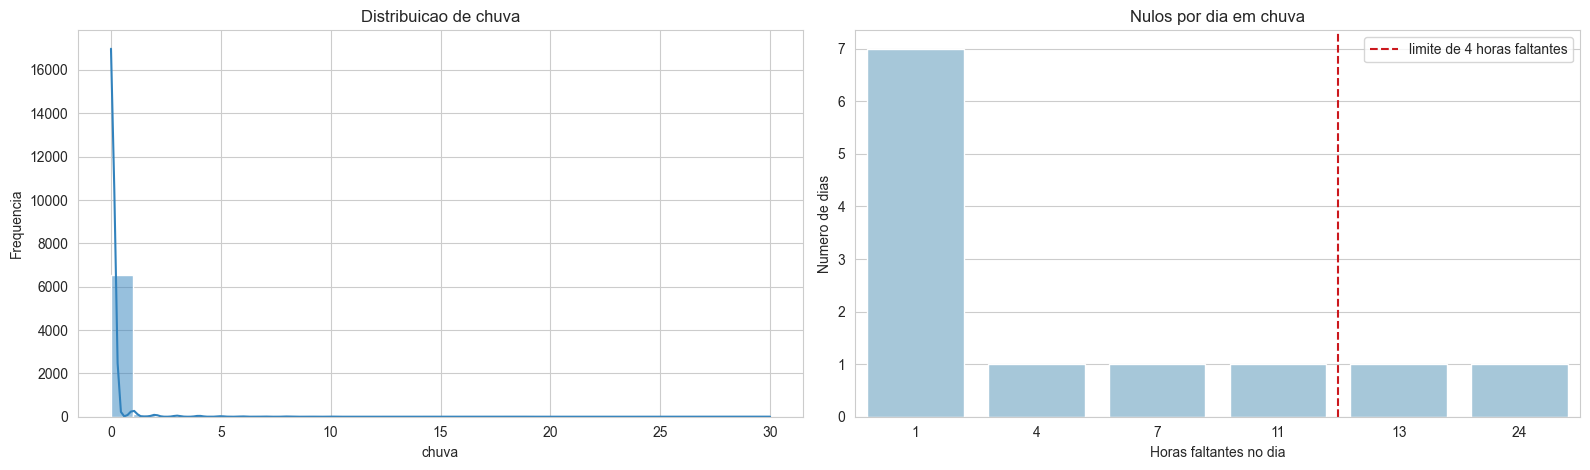

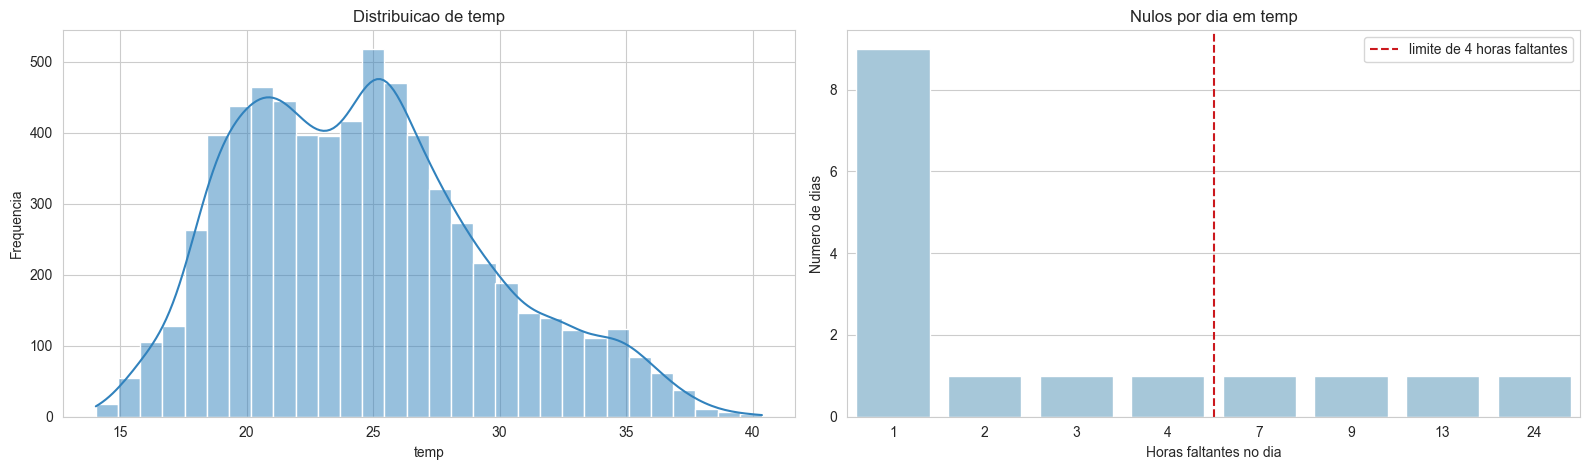

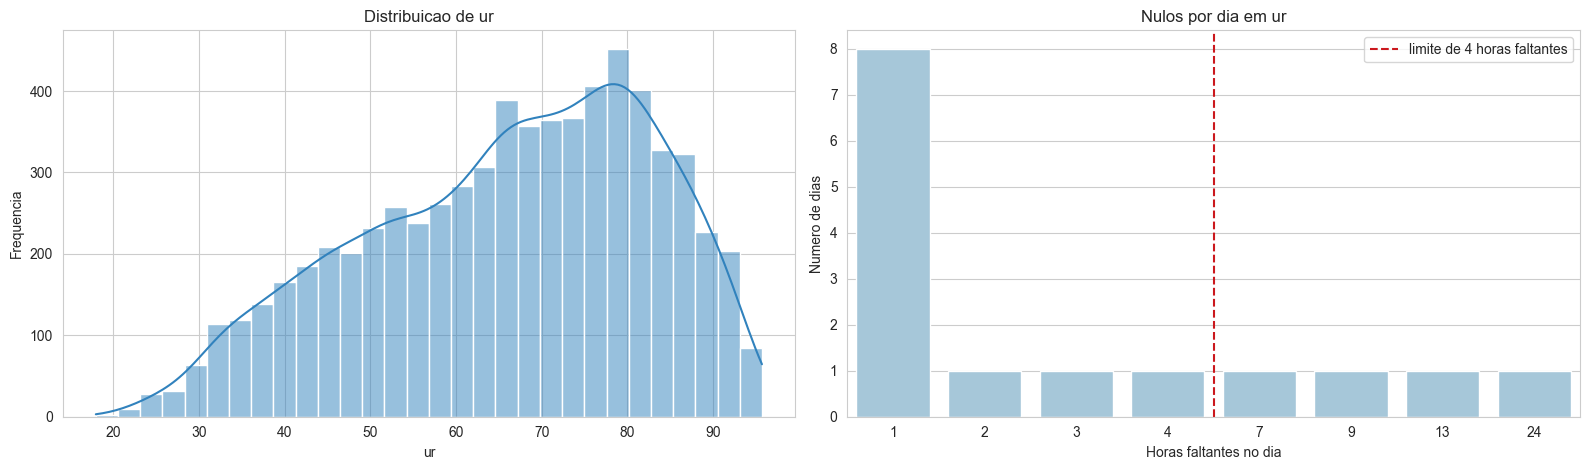

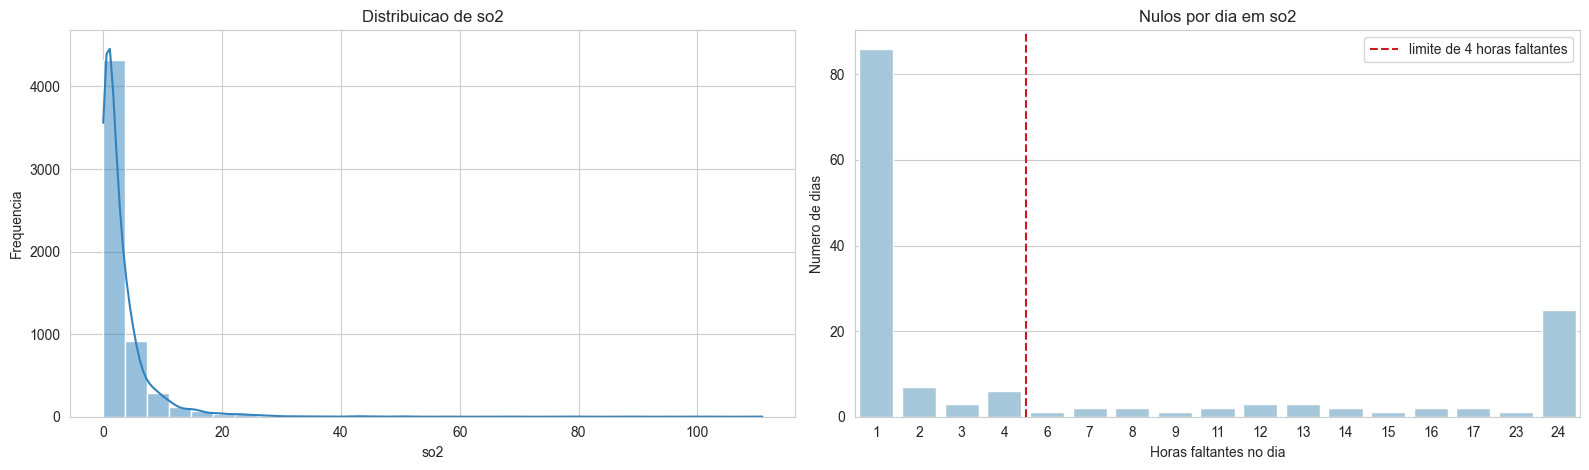

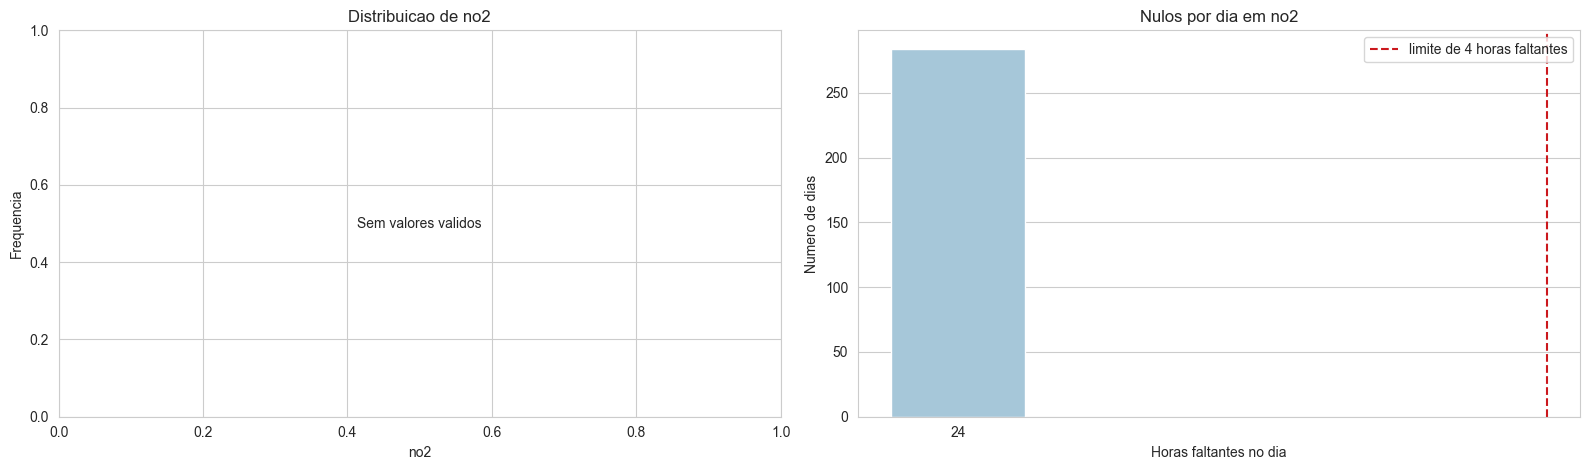

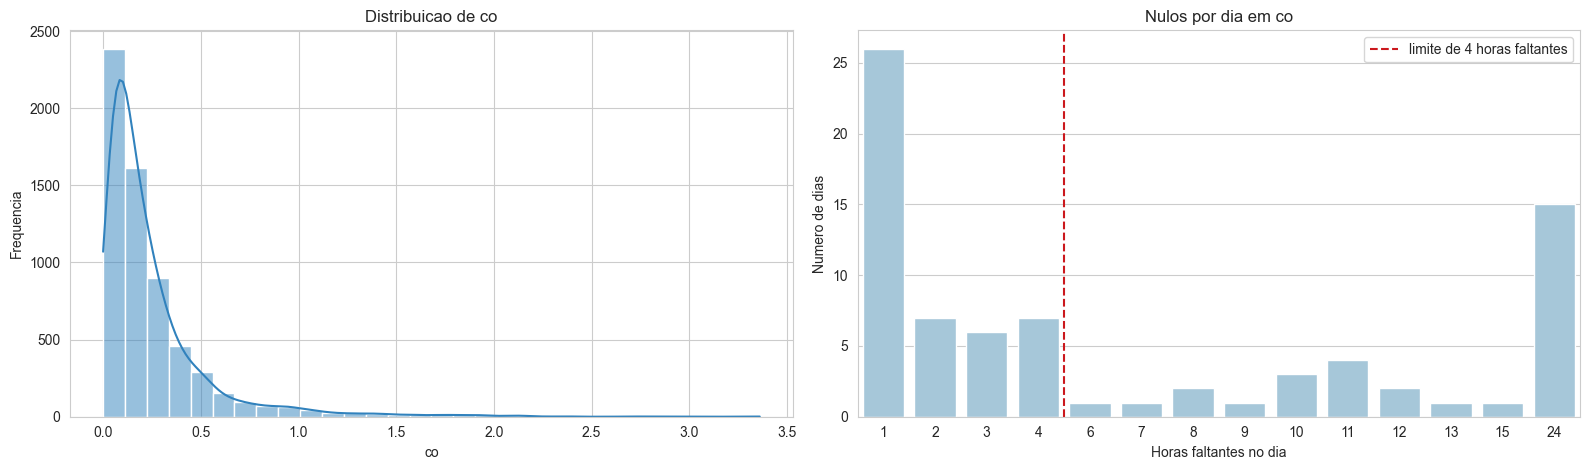

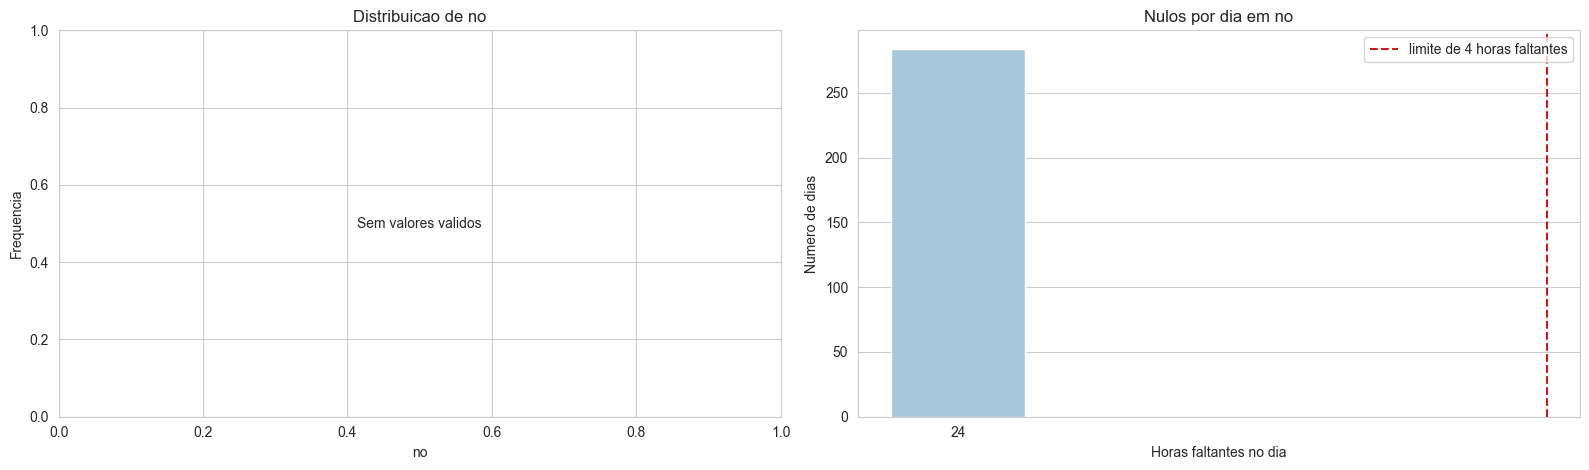

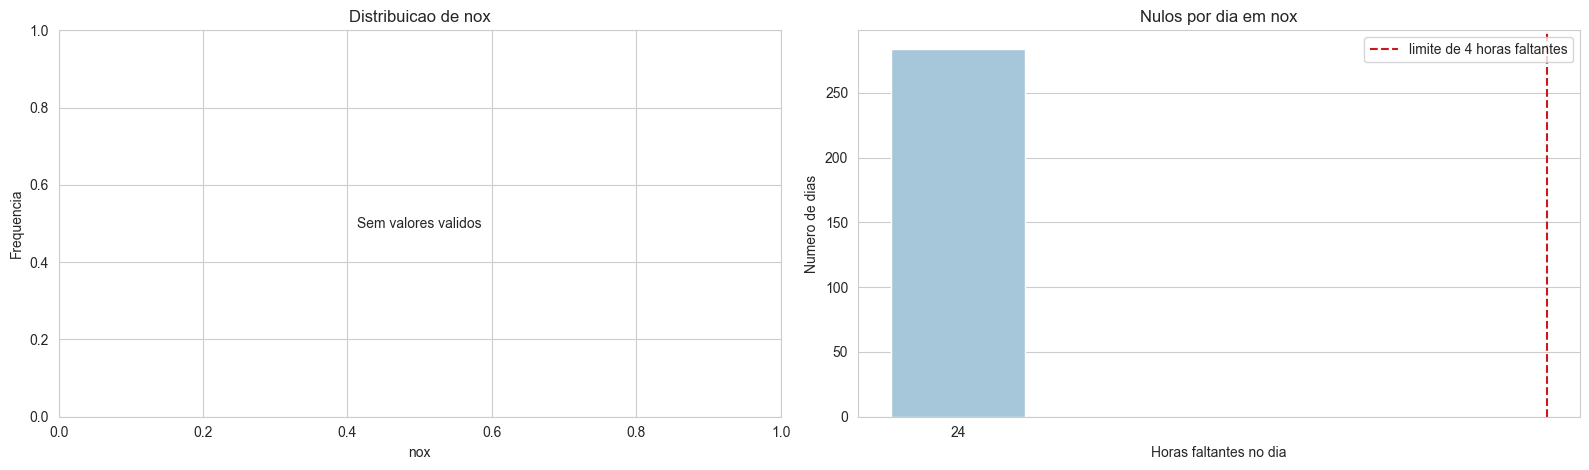

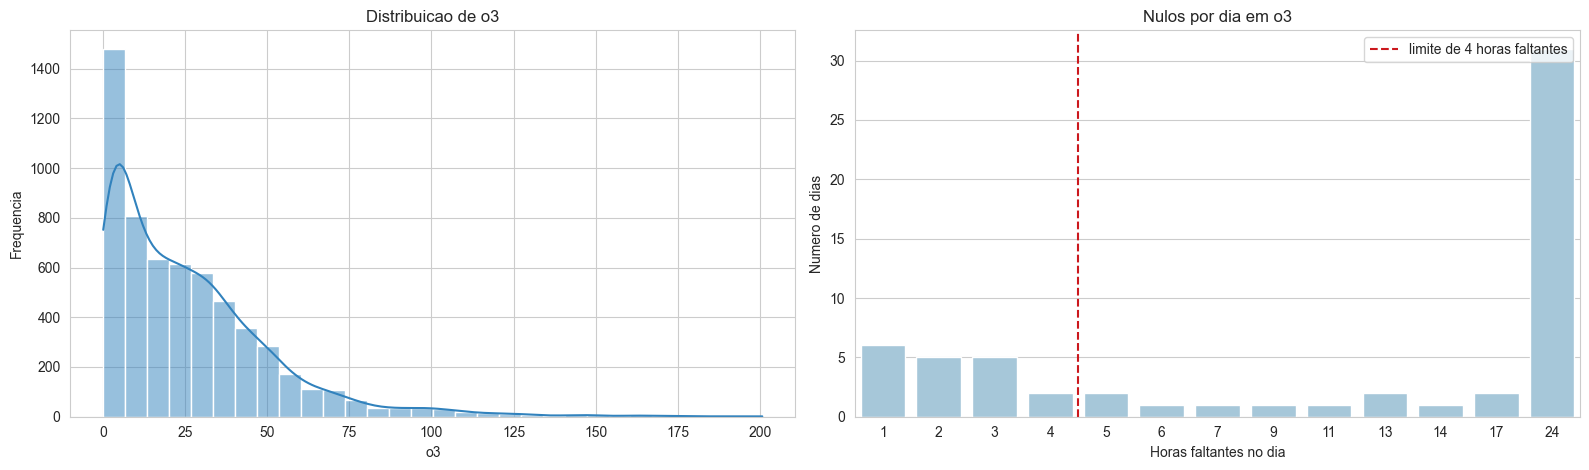

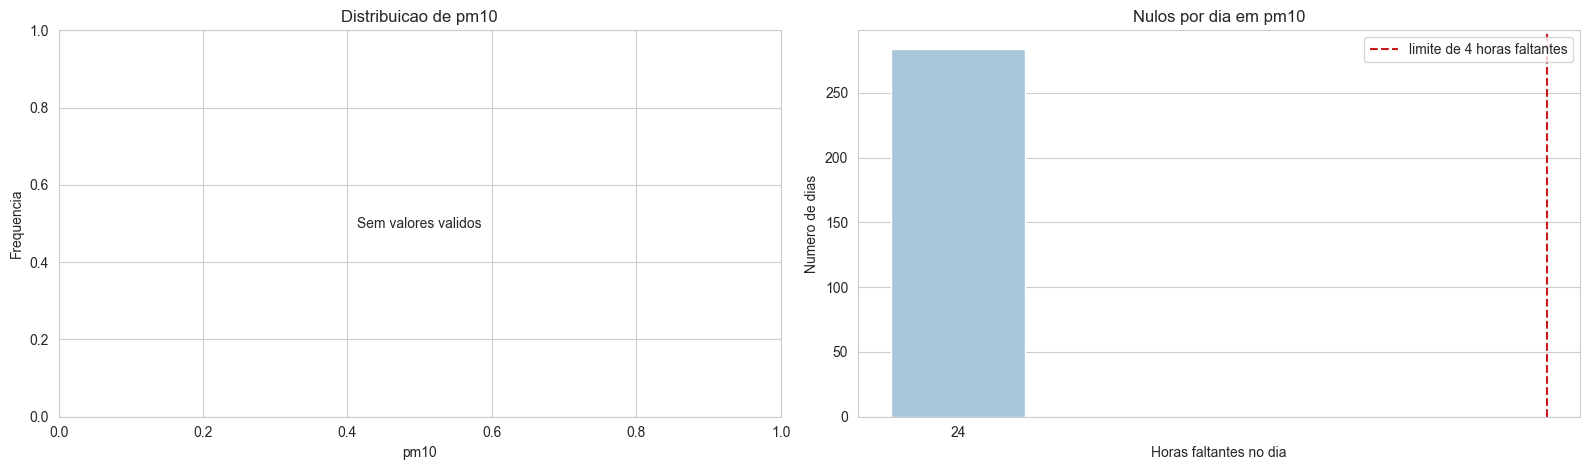

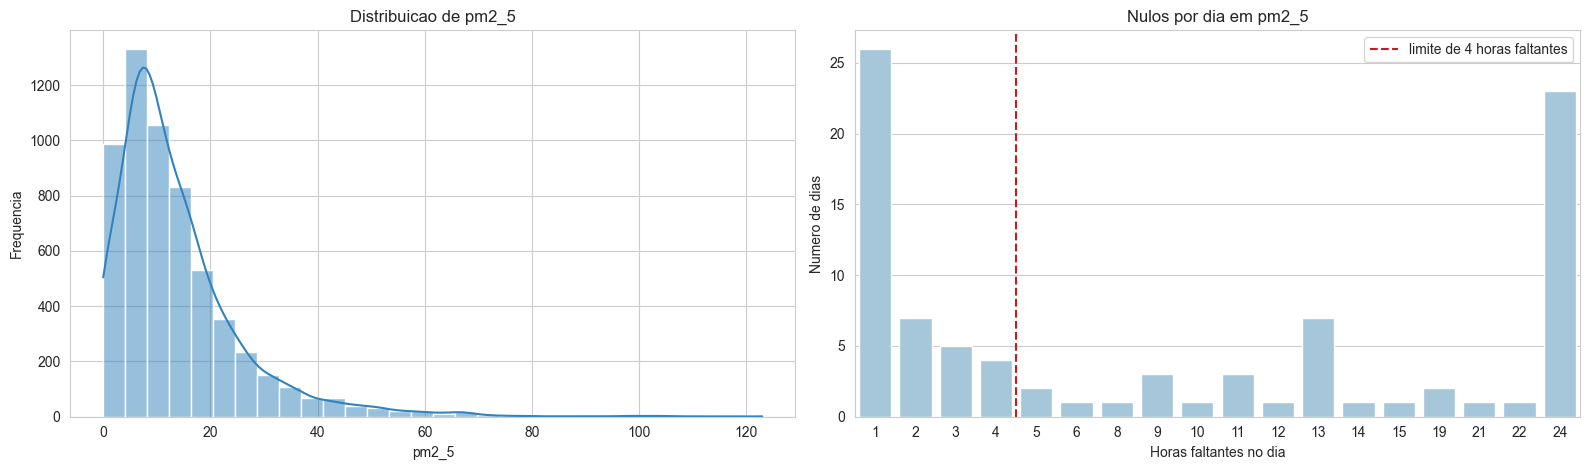

In [10]:
sns.set_style("whitegrid")

for variavel in variaveis_analise:
    serie = df_um_bangu_carac[variavel].dropna()
    faltantes_por_dia = distribuicoes_missing_diario[variavel]
    distribuicao_faltantes = (
        faltantes_por_dia.value_counts()
        .sort_index()
        .rename_axis("horas_faltantes")
        .reset_index(name="n_dias")
    )
    distribuicao_faltantes = distribuicao_faltantes[distribuicao_faltantes["horas_faltantes"] > 0].copy()

    fig, axes = plt.subplots(1, 2, figsize=(16, 4.8))

    if not serie.empty:
        sns.histplot(serie, bins=30, kde=True, color="#3182bd", ax=axes[0])
    else:
        axes[0].text(0.5, 0.5, "Sem valores validos", ha="center", va="center", transform=axes[0].transAxes)

    axes[0].set_title(f"Distribuicao de {variavel}")
    axes[0].set_xlabel(variavel)
    axes[0].set_ylabel("Frequencia")

    if not distribuicao_faltantes.empty:
        sns.barplot(data=distribuicao_faltantes, x="horas_faltantes", y="n_dias", color="#9ecae1", ax=axes[1])
        axes[1].axvline(3.5, color="#cb181d", linestyle="--", linewidth=1.5, label="limite de 4 horas faltantes")
        axes[1].legend(loc="upper right")
    else:
        axes[1].text(0.5, 0.5, "Sem dias com horas faltantes", ha="center", va="center", transform=axes[1].transAxes)

    axes[1].set_title(f"Nulos por dia em {variavel}")
    axes[1].set_xlabel("Horas faltantes no dia")
    axes[1].set_ylabel("Numero de dias")

    plt.tight_layout()
    plt.show()

## Resumo interpretativo dos resultados

Os resultados indicam que a Unidade Movel Bangu tem uma base **boa do ponto de vista temporal e operacional**, mas com um perfil diferente das estacoes fixas. A serie cobre um periodo bem mais curto, de `2016-12-01 00:30` a `2017-09-10 10:30`, sem duplicatas de horario e com estabilidade de nome e coordenadas. Ao mesmo tempo, ha `45` timestamps faltantes em `6803` esperados, o que mostra que a linha do tempo e relativamente consistente, mas nao totalmente continua. Assim, nesta unidade, o principal cuidado analitico envolve ao mesmo tempo a janela curta de observacao e a disponibilidade desigual entre as variaveis monitoradas.

A leitura de missing por variavel mostra uma separacao forte de qualidade. `no`, `no2`, `nox` e `pm10` estao estruturalmente indisponiveis (`100%` de nulos) e, neste recorte, nao devem ser tratados como series analisaveis. Entre as variaveis disponiveis, `so2` (`14,0%`), `pm2_5` (`12,9%`) e `o3` (`12,5%`) tem perdas relevantes, enquanto `co` aparece em uma situacao intermediaria (`8,2%`). Em contraste, `chuva`, `temp` e `ur` tem cobertura muito alta, com missing abaixo de `0,2%`, o que as torna as series mais confiaveis da unidade do ponto de vista de completude.

As distribuicoes reforcam que a unidade monitora processos heterogeneos em um conjunto mais enxuto de variaveis. Entre as meteorologicas, `chuva` volta a ser fortemente concentrada em zero e muito assimetrica, enquanto `temp` e `ur` apresentam comportamento mais estavel. Entre os poluentes efetivamente disponiveis, `co`, `o3`, `pm2_5` e `so2` mostram **assimetria a direita**, indicando muitos valores usuais e alguns episodios elevados. Esse padrao e especialmente forte em `so2` e `co`, mas tambem aparece de forma importante em `pm2_5` e `o3`, sugerindo que a unidade pode capturar eventos agudos relevantes mesmo em uma janela temporal relativamente curta.

A distribuicao diaria de nulos tambem ajuda a separar o que e lacuna curta do que e indisponibilidade estrutural. `chuva`, `temp` e `ur` concentram a maior parte dos dias completos e apresentam poucas falhas severas, o que favorece imputacao local simples quando necessario. `co`, `o3` e `pm2_5` ainda preservam boa quantidade de dias utilizaveis, mas ja acumulam um volume nao desprezivel de dias com perdas mais extensas. `so2` merece atencao especial porque combina muitos dias com lacunas curtas com um conjunto relevante de dias severamente incompletos. Ja `no`, `no2`, `nox` e `pm10` nao apresentam um problema de preenchimento pontual: essas series estao estruturalmente ausentes na unidade.

Em sintese, a Unidade Movel Bangu parece **util como plataforma de monitoramento de campanha**, porque a base e relativamente consistente, os metadados sao estaveis e varias variaveis-chave tem cobertura suficiente para analise. O principal limite analitico, porem, esta na combinacao entre janela curta de observacao e conjunto incompleto de sensores: `no`, `no2`, `nox` e `pm10` devem ser excluidos ou marcados como indisponiveis, `so2`, `pm2_5` e `o3` exigem mais controle de completude, e `chuva`, `temp`, `ur` e, em menor grau, `co` podem seguir com boa utilidade para as proximas etapas da EDA. Isso deixa claro que, nesta unidade, a confiabilidade e razoavel no nivel da base, mas a capacidade analitica fica concentrada em um subconjunto especifico de variaveis e em um intervalo temporal curto.
